In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
data=pd.read_csv(r"C:\Users\Ammar\Downloads\googleplaystore.csv")
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
data.shape

(10841, 13)

In [4]:
data.dropna(inplace=True)


In [5]:
data.shape

(9360, 13)

In [38]:
data.describe()

,Rating,Size,Price,Year
count,9360.000000,7723.000000,9360.000000,9360.000000
mean,4.191838,22.970120,0.961279,2017.420192
std,0.515263,23.449949,15.821640,1.102038
min,1.000000,0.008301,0.000000,2010.000000
25%,4.000000,5.300000,0.000000,2017.000000
50%,4.300000,14.000000,0.000000,2018.000000
75%,4.500000,33.000000,0.000000,2018.000000
max,5.000000,100.000000,400.000000,2018.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9360 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9360 non-null   object 
 1   Category        9360 non-null   object 
 2   Rating          9360 non-null   float64
 3   Reviews         9360 non-null   object 
 4   Size            9360 non-null   object 
 5   Installs        9360 non-null   object 
 6   Type            9360 non-null   object 
 7   Price           9360 non-null   object 
 8   Content Rating  9360 non-null   object 
 9   Genres          9360 non-null   object 
 10  Last Updated    9360 non-null   object 
 11  Current Ver     9360 non-null   object 
 12  Android Ver     9360 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1023.8+ KB


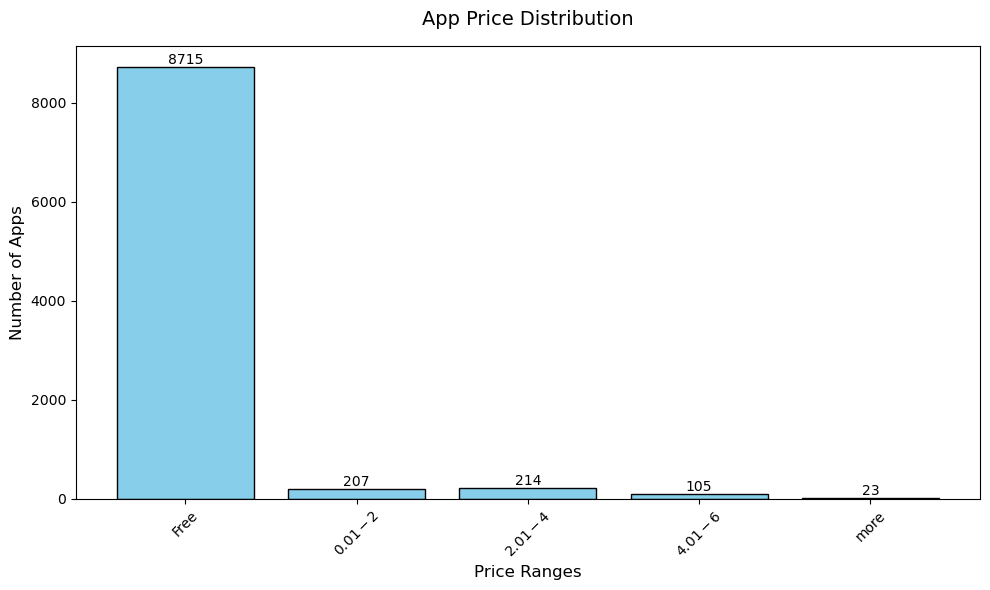

In [8]:
data.dropna(inplace=True)


# Convert price column to numeric, replacing non-numeric values with NaN
data['Price'] = pd.to_numeric(data['Price'].str.replace('$', ''), errors='coerce')

# Filter out NaN values
prices = data['Price'].dropna()

# Create price ranges for better visualization
bins = [0, 0.01, 2, 4, 6, 8]  # Price ranges
labels = ['Free', '$0.01-$2', '$2.01-$4', '$4.01-$6', 'more']

# Count frequencies for each bin
hist, _ = np.histogram(prices, bins=bins)

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(labels, hist, color='skyblue', edgecolor='black')

# Customize the chart
plt.title('App Price Distribution', fontsize=14, pad=15)
plt.xlabel('Price Ranges', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(hist):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [9]:
final_data = data['Category'].value_counts()


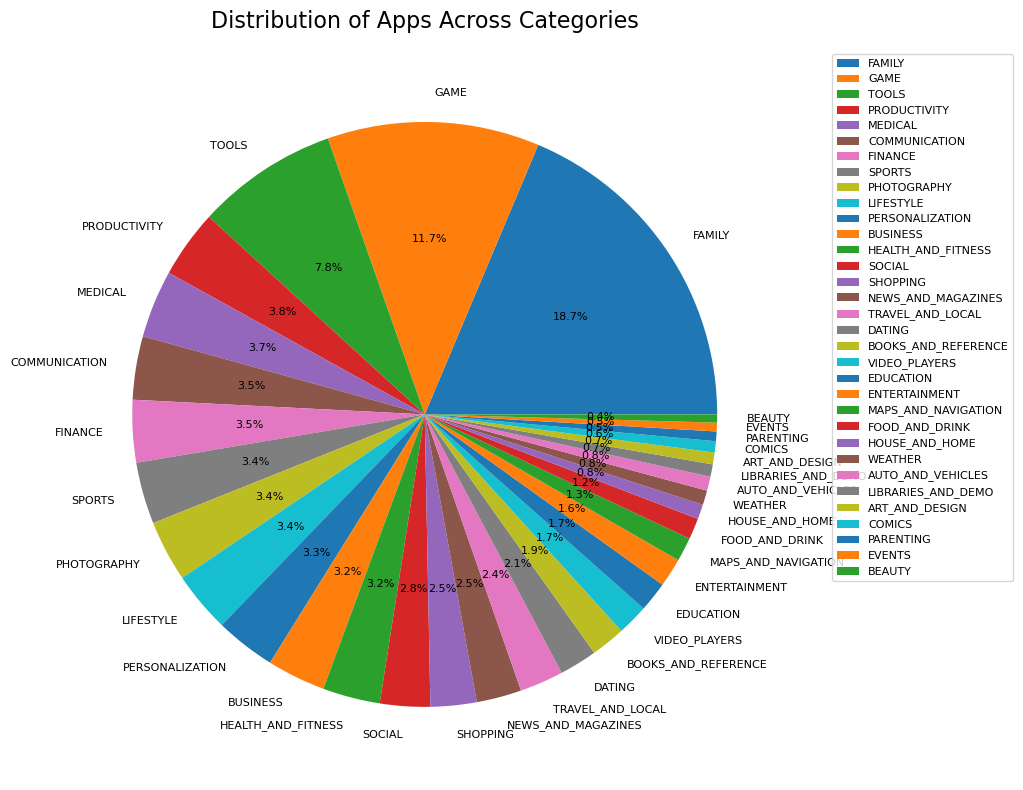

In [10]:
plt.figure(figsize=(12, 8))
plt.pie(final_data.values, 
        labels=final_data.index, 
        autopct='%1.1f%%',
        textprops={'fontsize': 8})  # حجم النصوص في الشارت

plt.title('Distribution of Apps Across Categories', fontsize=16, pad=15)  # عنوان الشارت

# إضافة وسيلة الإيضاح (Legend)
plt.legend(final_data.index, 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left', 
          fontsize=8)

plt.tight_layout()
plt.show()

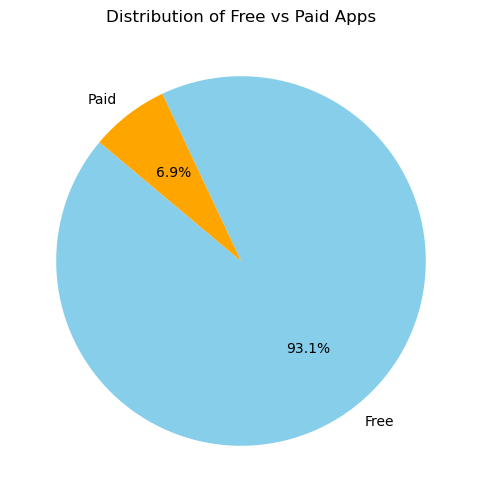

In [11]:
type_counts = data['Type'].value_counts()

labels = type_counts.index  # ['Free', 'Paid']
sizes = type_counts.values  
colors = ['skyblue', 'orange']

# رسم المخطط الدائري
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Distribution of Free vs Paid Apps')
plt.show()

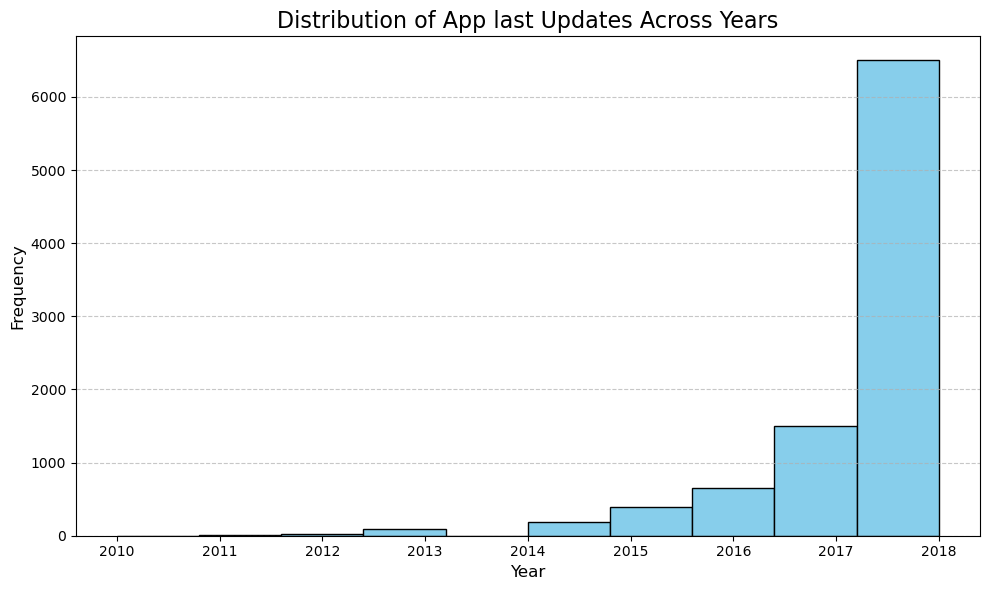

In [12]:
if 'Year' not in data.columns:
    data['Year'] = pd.to_datetime(data['Last Updated'], errors='coerce').dt.year

# رسم الرسم البياني للتوزيع
plt.figure(figsize=(10, 6))
plt.hist(data['Year'].dropna(), bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of App last Updates Across Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


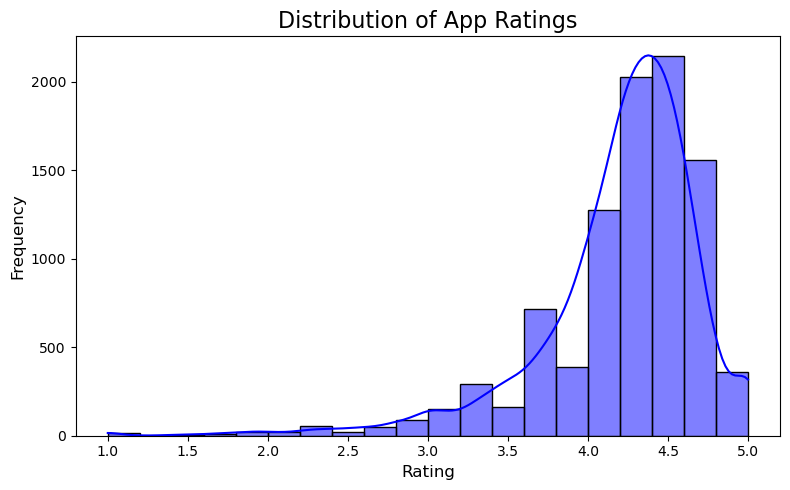

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Rating'], bins=20, kde=True, color='blue')
plt.title('Distribution of App Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

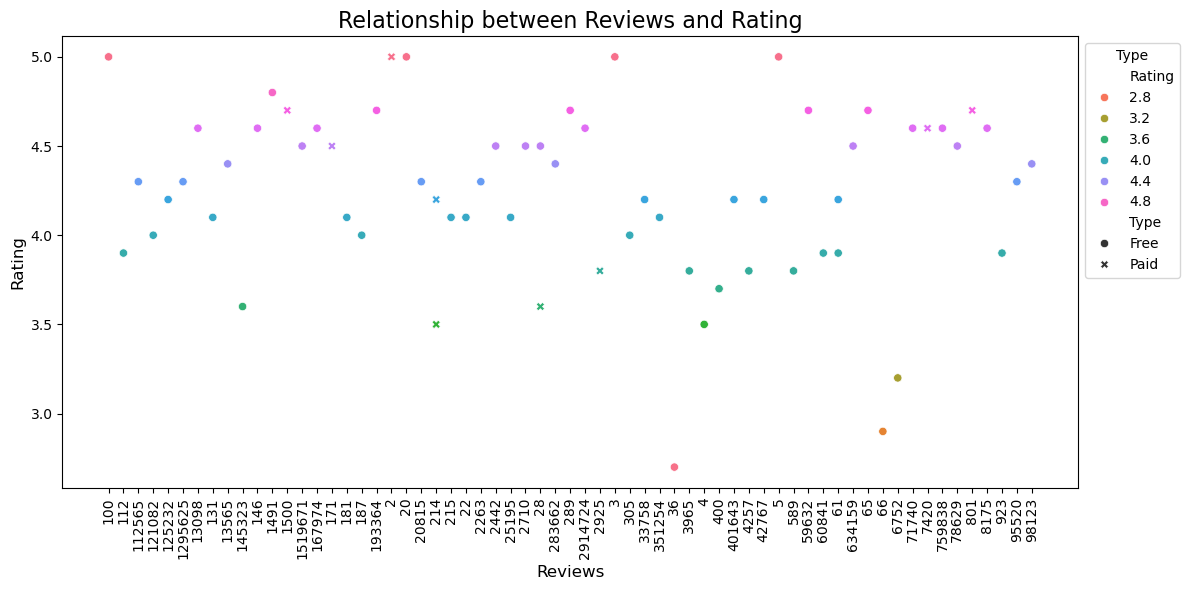

In [14]:
# أخذ عينة وترتيب البيانات تصاعديًا حسب 'Reviews'
sample_df = data.sample(n=66, random_state=42).sort_values(by='Reviews', ascending=True)

# رسم المخطط
plt.figure(figsize=(12, 6))
ax = sns.scatterplot(data=sample_df, x='Reviews', y='Rating', hue="Rating", style="Type", palette="husl")
plt.title('Relationship between Reviews and Rating', fontsize=16)
plt.xlabel('Reviews', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Type')
plt.tight_layout()
plt.show()


In [15]:
def clean_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', ''))  # تحويل MB إلى رقم
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024  # تحويل kB إلى MB
    return None  # القيم النصية غير الصالحة تصبح None

data['Size'] = data['Size'].apply(clean_size)


In [16]:
def size_category(size):
    if size is None:
        return 'Unknown'  # إذا لم يكن الحجم معروفًا
    elif size < 10:
        return 'Small'
    elif 10 <= size <= 70:
        return 'Medium'
    else:
        return 'Large'

data['Size Category'] = data['Size'].apply(size_category)


In [17]:
data[['App', 'Size', 'Size Category']].head()


,App,Size,Size Category
0,Photo Editor & Candy Camera & Grid & ScrapBook,19.0,Medium
1,Coloring book moana,14.0,Medium
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",8.7,Small
3,Sketch - Draw & Paint,25.0,Medium
4,Pixel Draw - Number Art Coloring Book,2.8,Small


C:\Users\Ammar\AppData\Local\Temp\ipykernel_11084\1474235952.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Size Category', palette='viridis')


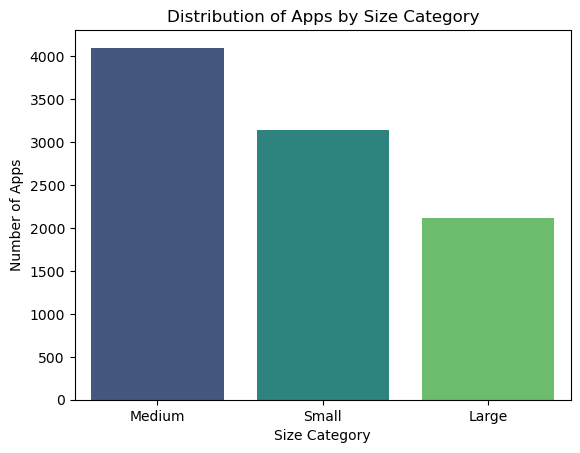

In [18]:

sns.countplot(data=data, x='Size Category', palette='viridis')
plt.title('Distribution of Apps by Size Category')
plt.xlabel('Size Category')
plt.ylabel('Number of Apps')
plt.show()
